<div style = "color:blue; font-size:25px">The goal of this project is to analyze factors affecting student's academic performance.

<div style = "color:blue; font-size:20px">Author: Kartika Nidhi<br>
Email: kartikanidhi@gmail.com<br>
LinkedIn: Kartika Nidhi
</div>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas import Series, DataFrame


<div style = "color:blue; font-size:25px">1. Loading Dataset

In [7]:
data = pd.read_csv('/home/kartika/Datasets/student_data.csv')
data.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


<div style = "color:blue; font-size:25px">2. Basic Info about Dataset


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [13]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [14]:
data.duplicated().sum()

np.int64(0)

<div style = "color:blue; font-size:20px">No missing values and duplicate values.

<div>

<div>

<div style = "color:blue; font-size:25px">3. Filtering necessary columns

In [5]:
data.columns.unique()

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

<div style = "color:blue; font-size:20px">Out of 33 columns,(school, sex, age, address, famsize, Parent Status, Medu, Fedu, Mjob, Fjob, traveltime, studytime
, failures, internet, freetime, goout, health, absences, G3) will be focused columns for this analysis.

In [8]:
data = data[['school','sex','age','address','famsize','Pstatus','Medu','Fedu','Mjob','Fjob','traveltime','studytime','failures','internet',
'freetime','absences','G1','G2','G3']]
data.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,traveltime,studytime,failures,internet,freetime,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,2,2,0,no,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,1,2,0,yes,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,1,2,3,yes,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,1,3,0,yes,2,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,1,2,0,no,3,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,1,2,0,yes,4,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,1,2,0,yes,4,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,2,2,0,no,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,1,2,0,yes,2,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,1,2,0,yes,5,0,14,15,15


<div>

<div>

<div style = "color:blue; font-size:25px">4. Univariate Analysis

<div style = "color:blue; font-size:25px">4.1 Sex Distribution

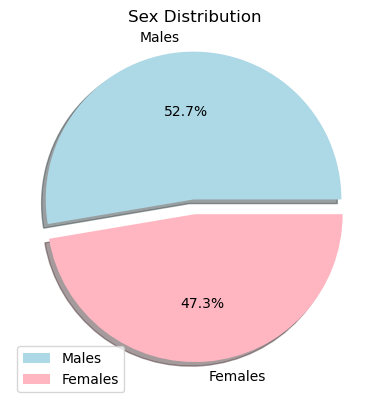

In [4]:
plt.pie(data['sex'].value_counts(), labels=['Males','Females'], explode = [0.1,0.0],colors = ['lightblue','lightpink'], autopct = "%1.1f%%", shadow = True)
plt.title("Sex Distribution")

plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The distribution is almost balanced, but males are slightly more represented.

<div style = "color:blue; font-size:25px">4.2 Age Distribution

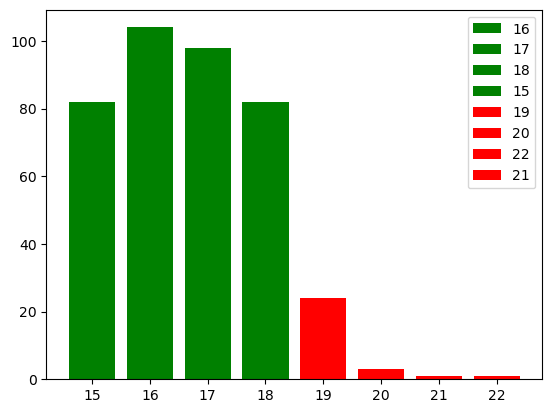

In [40]:
plt.bar(data['age'].value_counts().index, data['age'].value_counts().values,
 color = ['green','green','green','green','red','red','red','red'], label = data['age'].value_counts().index)

plt.legend()
plt.show()

<div style = "color:blue; font-size:20px"> The dataset is dominated by teenagers (15-18), with highest reprsentation, while individuals above 19 years
constitue the smallest proportion.

<div style = "color:blue; font-size:25px">4.3 Urban vs Rural

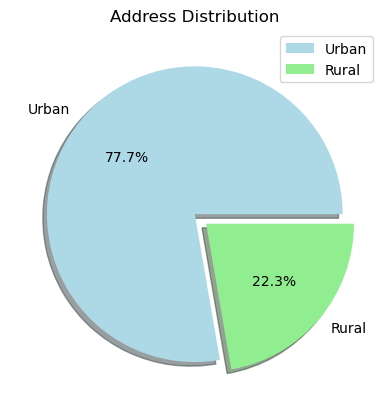

In [5]:
plt.pie(data.address.value_counts(), labels =['Urban','Rural'], explode = [0.0,0.1], colors = ['lightblue','lightgreen'], autopct = "%1.1f%%", shadow = True)

plt.title("Address Distribution")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The dataset is heavily dominated by urban students, while rural students account for much smaller proportion.

<div style = "color:blue; font-size:25px">4.4 Family Size Distribution

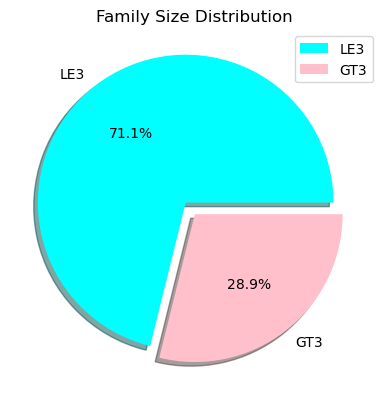

In [9]:
plt.pie(data.famsize.value_counts(), colors = ['cyan','pink'], labels = ['LE3','GT3'], explode = [0.1,0.0], autopct = "%1.1f%%", shadow = True)

plt.title("Family Size Distribution")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">Most of the students, which is more than two/third of the students
belong to nuclear family, LE3 (Less than equal to three members). While, close to one/third of students belong to family with members greater than three.  

<div style = "color:blue; font-size:25px">4.5 Parents Status

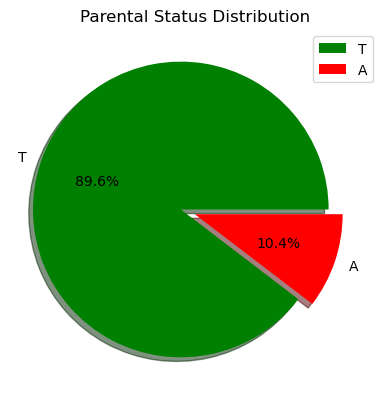

In [10]:
plt.pie(data.Pstatus.value_counts(), colors = ['green','red'], labels = ['T','A'], explode = [0.1,0.0], autopct = "%1.1f%%", shadow = True)

plt.title("Parental Status Distribution")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">Most of the student's parents live together that is almost 90% of the total. While, few student's parents that is 10% of the total live apart.

<div style = "color:blue; font-size:25px">4.6 Parental Education Status

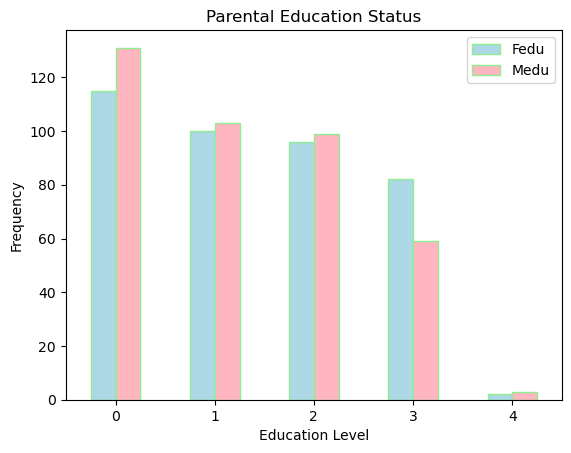

In [4]:
pedu = DataFrame({
    'Fedu':data.Fedu.value_counts().values,
    'Medu':data.Medu.value_counts().values
}, index = [0,1,2,3,4])


#To show bars one on top of each
# plt.bar(data.Fedu.value_counts().index, data.Fedu.value_counts().values, color = 'lightblue', label = 'Father Education', edgecolor = 'green')
# plt.bar(data.Medu.value_counts().index, data.Medu.value_counts().values, color = 'lightpink', label = 'Mother Education', edgecolor = 'green')

#To show bars side by side
pedu.plot(kind = 'bar', color = ['lightblue','lightpink'], edgecolor = 'lightgreen', label = ['Father Education','Mother Education'])

plt.title('Parental Education Status')
plt.xlabel('Education Level')
plt.ylabel('Frequency')
plt.xticks(rotation = 0)
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">Education Level Description:
<ul>
<li>0 : None</li>
<li>1 : Primary(4th grade)</li>
<li>2 : 4th-9th grade</li>
<li>3 : Secondary</li>
<li>4 : Higher </li>
</ul>
</div>


<div style = "color:blue; font-size:20px">The chart indicates parents with generally low formal education. While mothers are slightly more likely to have primary-level schooling, fathers are notably more likely to reach a secondary education level. Overall, most the parents have education upto Secondary Level.</div>

<div style = "color:blue; font-size:25px">4.7 Parents Job Status

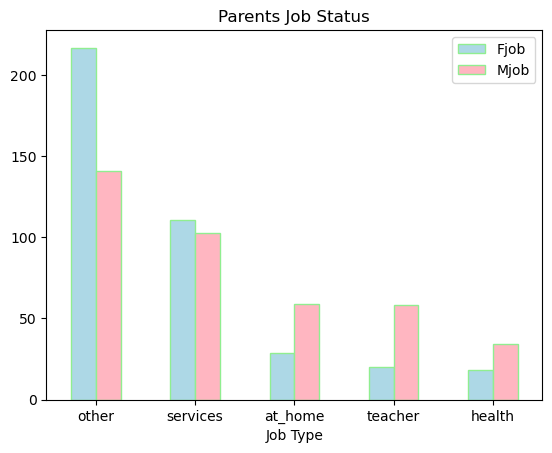

In [5]:
job = DataFrame({
    'Fjob':data.Fjob.value_counts().values,
    'Mjob':data.Mjob.value_counts().values
}, index = data.Mjob.value_counts().index)

job.plot(kind = 'bar', color = ['lightblue','lightpink'], edgecolor = 'lightgreen', label = ["Father's Job","Mother's  Job"], xlabel = 'Job Type')

plt.title("Parents Job Status")
plt.xticks(rotation = 0)
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The data shows that while a large portion of both parents work in "other" or "services" roles, there is a clear trend of mothers being more represented in teaching, healthcare, and stay-at-home positions, while fathers are more heavily concentrated in the "other" employment category.

<div style = "color:blue; font-size:25px">4.8 StudyTime

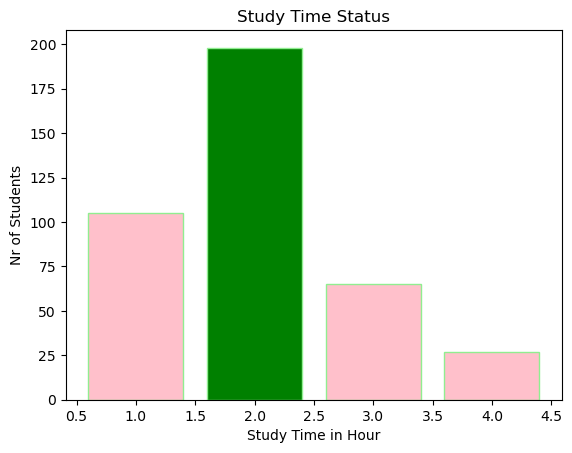

In [6]:
plt.bar(data.studytime.value_counts().index, data.studytime.value_counts().values, color = ['green','pink','pink','pink'], edgecolor = 'lightgreen')

plt.title("Study Time Status")
plt.xlabel("Study Time in Hour")
plt.ylabel("Nr of Students")
plt.show()

<div style = "color:blue; font-size:20px">2 Hours seems to be common study time for majority of students. While, 1 and 3 hours is common in moderate number of students. Only few number of students have 4 hours of study time.

<div style = "color:blue; font-size:25px"> 4.9 Internet Access Status

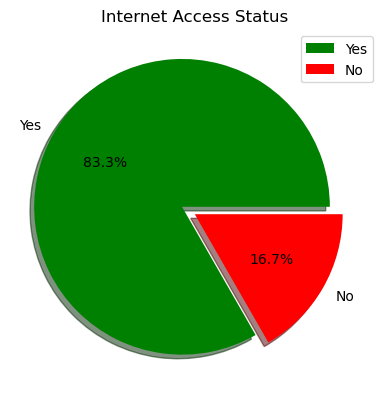

In [33]:
plt.pie(data.internet.value_counts(), colors = ['green','red'], labels = ['Yes','No'], explode = [0.1,0.0], autopct = "%1.1f%%", shadow = True)


plt.title("Internet Access Status")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">Internet Access seems to be very common among students, with 83% students. While, nearly 17% students have no internet
access.

<div style = "color:blue; font-size:20px">4.10 Absences Status

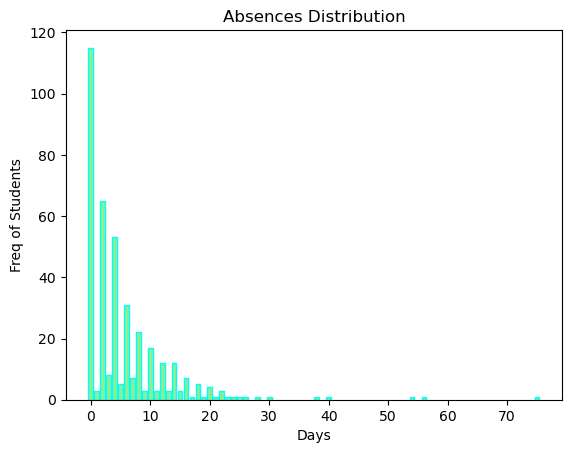

In [7]:
plt.bar(data.absences.value_counts().index, data.absences.value_counts().values, color = 'lightgreen', edgecolor = 'cyan')

plt.title("Absences Distribution")
plt.xlabel("Days")
plt.ylabel("Freq of Students")
plt.show()


<div style = "color:blue; font-size:20px">The graph shows that most of the students are regular with absence of less than 10 days. While few students tends to irregular.

<div style = "color:blue; font-size:25px">4.11 G3(Final Score)[Target Variable]

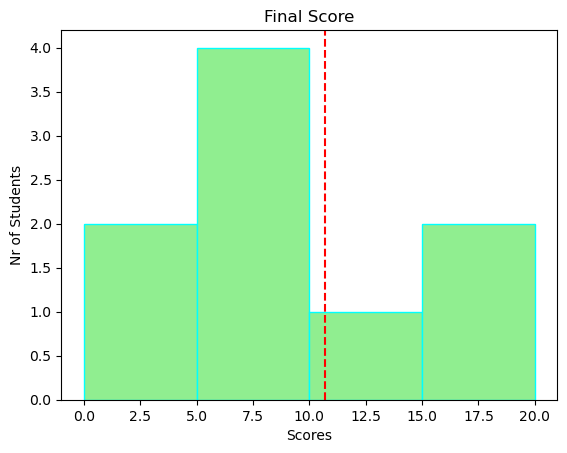

In [16]:
bins = np.arange(0,21,5)
plt.hist(data.G3.value_counts().values, bins= bins, color = 'lightgreen', edgecolor = 'cyan')


mean_score = ((data['G1']+data['G2']+data['G3'])/3).mean()
plt.axvline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title('Final Score')
plt.xlabel('Scores')
plt.ylabel('Nr of Students')
plt.show()

<div style = "color:blue; font-size:20px">Most of the students scored between 5-10. Nr. of students scoring below 5 is same as students scoring above 15 that is nr. of least scoring and high scoring students are same.
Overall, students with different test score represent the data.

<div style = "color:blue; font-size:20px">Also, from the mean line, most of the students have scored below average.

<div>

<div>

<div>

<div style = "color:blue; font-size:25px">5. Bivariate Analysis

<div style = "color:blue; font-size:25px">5.1 Sex vs Score

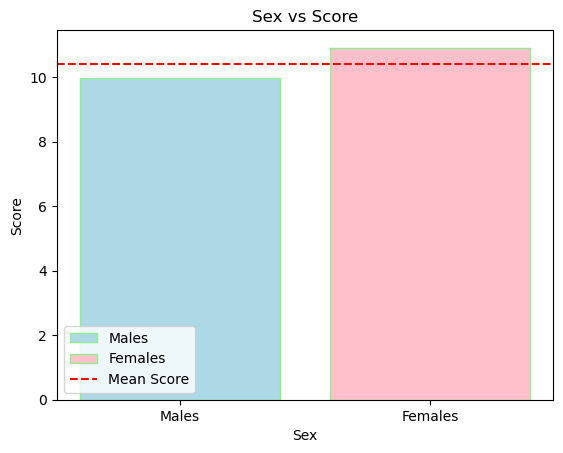

In [19]:
plt.bar(['Males','Females'],data.G3.groupby(data["sex"]).mean(), color = ['lightblue','pink'], edgecolor = 'lightgreen', label = ['Males','Females'])


mean_score = (data['G3']).mean()
plt.axhline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Sex vs Score")
plt.xlabel("Sex")
plt.ylabel("Score")                                                                                                
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The above chart shows that females are comparatively higher scorer than males with slightly greater average score.

<div style = "color:blue; font-size:25px">5.2 Age vs Score

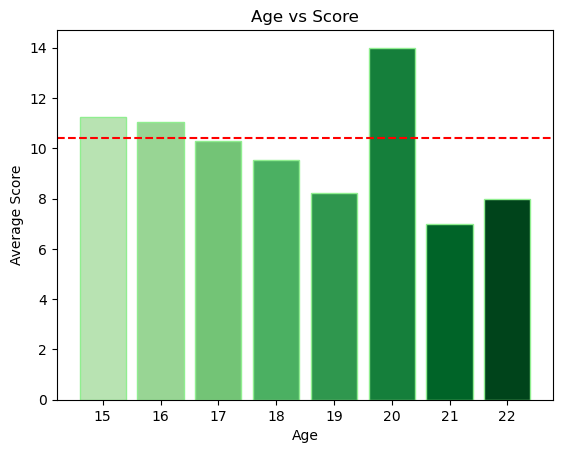

In [25]:
plt.bar(['15','16','17','18','19','20','21','22'],data.G3.groupby(data["age"]).mean(), color = plt.cm.Greens(np.linspace(0.3,1,8)),
         edgecolor = 'lightgreen')


mean_score = (data['G3']).mean()
plt.axhline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Age vs Score")
plt.xlabel("Age")                                                                                      
plt.ylabel("Average Score")
plt.show()

<div style = "color:blue; font-size:20px">Students aged 20 are the highest scorer among other students. Students aged 15 and 16 are second highest scorer with scores slightly greater than the mean score. Students aged 18,19,21 and 22 are below average scorer students. Overall, teeagers are likely to score above average, whereas adults are likely to score below average exception:aged20.

<div style = "color:blue; font-size:25px">5.3 Address vs Score

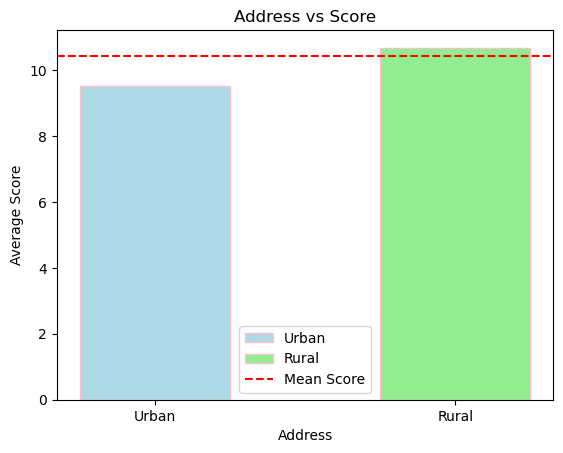

In [29]:
plt.bar(['Urban','Rural'],data.G3.groupby(data["address"]).mean(), color = ['lightblue','lightgreen'], edgecolor = 'pink', label = ['Urban','Rural'], width = 0.5)


mean_score = (data['G3']).mean()
plt.axhline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Address vs Score")
plt.xlabel("Address")                                                                                      
plt.legend()
plt.ylabel("Average Score")
plt.show()

<div style = "color:blue; font-size:20px">From previous univariate analysis of address, eventhough there is majority of urban students, rural students tends to score higher than urban students and above average.

<div style = "color:blue; font-size:25px">5.4 Family Size vs Score

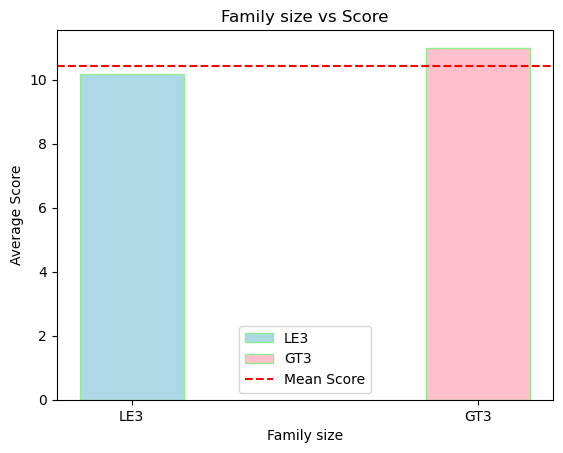

In [32]:
plt.bar(['LE3','GT3'],data.G3.groupby(data["famsize"]).mean(), color = ['lightblue','pink'], edgecolor = 'lightgreen', label = ['LE3','GT3'], width = 0.3)


mean_score = (data['G3']).mean()
plt.axhline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Family size vs Score")
plt.xlabel("Family size")                                                                                      
plt.legend()
plt.ylabel("Average Score")
plt.show()

<div style = "color:blue; font-size:20px">Comparatively, students from big family tends to score higher and above average than students from nuclear family.

<div style = "color:blue; font-size:25px">5.5 Parents status vs Score

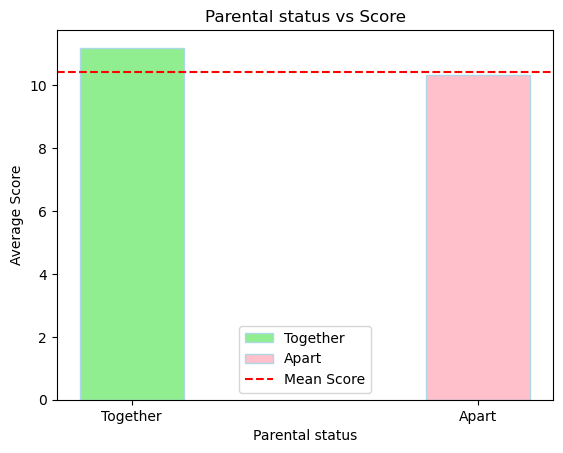

In [38]:
plt.bar(['Together','Apart'],data.G3.groupby(data["Pstatus"]).mean(), color = ['lightgreen','pink'], edgecolor = 'lightblue', label = ['Together','Apart'], width = 0.3)


mean_score = (data['G3']).mean()
plt.axhline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Parental status vs Score")
plt.xlabel("Parental status")                                                                                      
plt.legend()
plt.ylabel("Average Score")
plt.show()

<div style = "color:blue; font-size:20px">From the previous univariate analysis of parental status, majority of student's parent live together. Those studentstends to score higher and above average than students whose parents live apart.

<div style = "color:blue; font-size:25px">5.6 Study Time vs Score

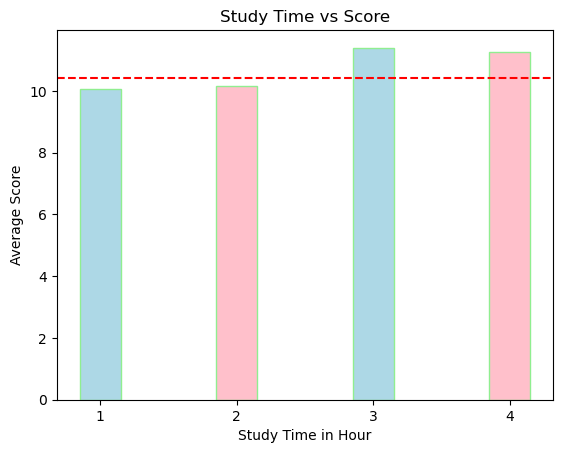

In [39]:
plt.bar(['1','2','3','4'],data.G3.groupby(data["studytime"]).mean(), color = ['lightblue','pink'], edgecolor = 'lightgreen', width = 0.3)


mean_score = (data['G3']).mean()
plt.axhline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Study Time vs Score")
plt.xlabel("Study Time in Hour")                                                                                      
plt.ylabel("Average Score")
plt.show()

<div style = "color:blue; font-size:20px">Study Time and Score have clear and direct relation. Students with higher study time 3-4 hours tends to score higher and above average compared to students with less study time.

<div style = "color:blue; font-size:25px"> 5.7 Attendence vs Score

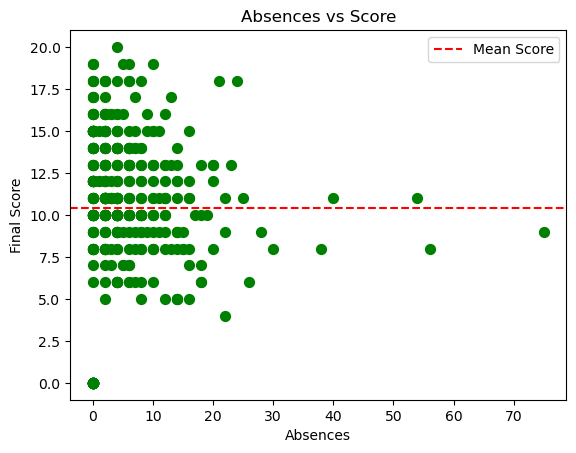

In [16]:
plt.scatter(data['absences'],data['G3'], color = 'green', marker = 'o', s = 50)


mean_score = (data['G3']).mean()
plt.axhline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Absences vs Score")
plt.xlabel("Absences")                                                                                                          
plt.legend()
plt.ylabel("Final Score")
plt.show()

<div style = "color:blue; font-size:20px">Here, students with high attendence/low absences tends to score higher compared to irregular and more absent students.
Also, in low absences, there is equal distribution of students scoring below and above average score.

<div style = "color:blue; font-size:25px">5.8 Internet Access vs Score

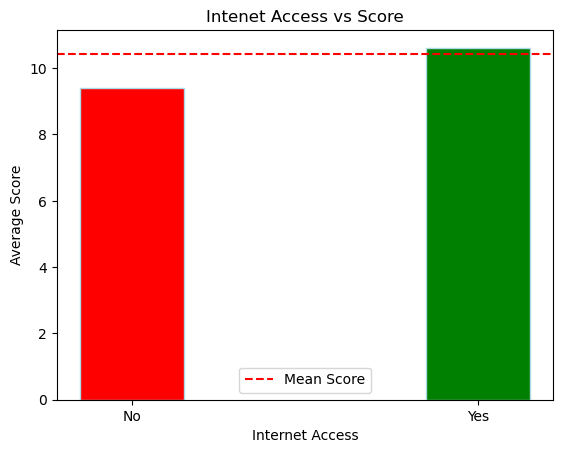

In [19]:
plt.bar(['No','Yes'],data.G3.groupby(data["internet"]).mean(), color = ['red','green'], edgecolor = 'lightblue', width = 0.3)


mean_score = (data['G3']).mean()
plt.axhline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Intenet Access vs Score")
plt.xlabel("Internet Access")                                                                                                          
plt.legend()
plt.ylabel("Average Score")
plt.show()

<div style = "color:blue; font-size:20px">Here, students with internet access tends to score higher and above average compared to students with no internet access.

<div>

<div>

<div style = "color:blue; font-size:25px">6. Multivariate Analysis

<div style = "color:blue; font-size:25px">6.1 Parents Education vs Score of Students